# **Heart Disease Prediction Using Machine Learning**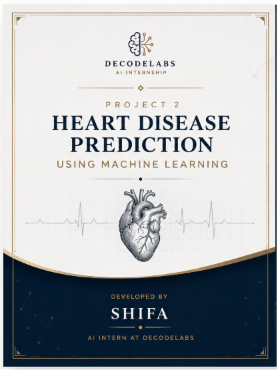

**Import Required Libraries**

In [1]:
# ==========================================================
# Project Title: Heart Disease Prediction Using Machine Learning
# Intern: Shifa
# Organization: DecodeLabs
# ==========================================================

# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Set Visualization Style
sns.set_style("whitegrid")

print("=" * 60)
print(" Heart Disease Prediction Project Initialized Successfully ")
print("=" * 60)

 Heart Disease Prediction Project Initialized Successfully 


**Load Dataset & Preview**

In [5]:
import os

for file in os.listdir():
    print(file)

.config
sample_data


In [6]:
# ==========================================================
# CELL 2 : Upload & Load Dataset (Google Colab)
# ==========================================================

from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(file_name)

print("=" * 60)
print(" Heart Disease Dataset Loaded Successfully ")
print("=" * 60)

print(f"\nLoaded File : {file_name}")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
display(df.head())

Saving heart.csv to heart.csv
 Heart Disease Dataset Loaded Successfully 

Loaded File : heart.csv

Dataset Shape:
(303, 14)

First 5 Records:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


**Dataset Information & Data Quality Report**

In [7]:
# ==========================================================
# CELL 3 : Dataset Information & Data Quality Report
# ==========================================================

print("=" * 70)
print("           DATASET INFORMATION & QUALITY REPORT")
print("=" * 70)

# -----------------------------
# Basic Information
# -----------------------------
print("\n📌 Dataset Information:\n")
df.info()

# -----------------------------
# Shape
# -----------------------------
print("\n" + "="*70)
print("📌 Dataset Shape")
print("="*70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# -----------------------------
# Column Names
# -----------------------------
print("\n" + "="*70)
print("📌 Column Names")
print("="*70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# -----------------------------
# Missing Values
# -----------------------------
print("\n" + "="*70)
print("📌 Missing Values")
print("="*70)

missing = df.isnull().sum()

display(missing.to_frame(name="Missing Values"))

print(f"\n✅ Total Missing Values : {missing.sum()}")

# -----------------------------
# Duplicate Records
# -----------------------------
print("\n" + "="*70)
print("📌 Duplicate Records")
print("="*70)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

# -----------------------------
# Memory Usage
# -----------------------------
print("\n" + "="*70)
print("📌 Memory Usage")
print("="*70)

memory = df.memory_usage(deep=True).sum()/1024

print(f"{memory:.2f} KB")

# -----------------------------
# Final Dataset Status
# -----------------------------
print("\n" + "="*70)
print("📌 Final Dataset Status")
print("="*70)

if missing.sum()==0:
    print("✅ No Missing Values Found")
else:
    print("❌ Missing Values Detected")

if duplicates==0:
    print("✅ No Duplicate Records Found")
else:
    print(f"⚠️ {duplicates} Duplicate Record(s) Found")

print("\n🎉 Dataset Quality Check Completed Successfully!")

           DATASET INFORMATION & QUALITY REPORT

📌 Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

📌 Dataset Shape
Rows    : 303
Columns : 14

📌 Column Names
1. age
2. sex
3. cp
4. trestbps
5. chol
6. fbs
7. restecg
8. thalach
9. exang
10. oldp

,Missing Values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



✅ Total Missing Values : 0

📌 Duplicate Records
Duplicate Rows : 1

📌 Memory Usage
33.27 KB

📌 Final Dataset Status
✅ No Missing Values Found
⚠️ 1 Duplicate Record(s) Found

🎉 Dataset Quality Check Completed Successfully!


**Statistical Summary & Target Distribution**

      EXPLORATORY DATA ANALYSIS (EDA)

📌 Statistical Summary



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



📌 Target Variable Distribution
target
0    138
1    165
Name: count, dtype: int64

Percentage Distribution:
No Heart Disease: 45.54%
Heart Disease: 54.46%


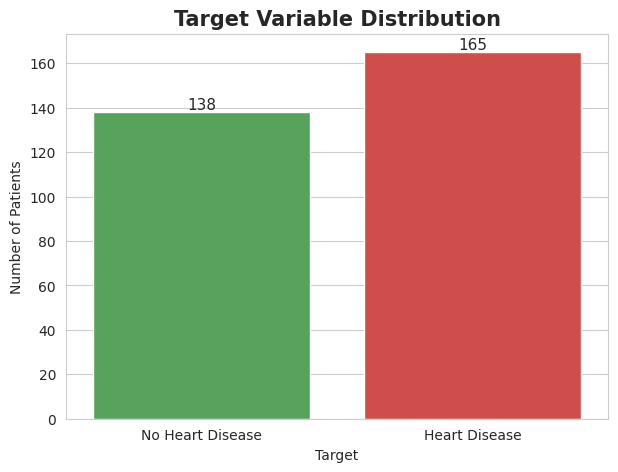


✅ Statistical Analysis Completed Successfully!


In [8]:
# ==========================================================
# CELL 4 : Statistical Summary & Target Variable Analysis
# ==========================================================

print("=" * 70)
print("      EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 70)

# -----------------------------
# Statistical Summary
# -----------------------------
print("\n📌 Statistical Summary\n")

display(df.describe())

# -----------------------------
# Target Distribution
# -----------------------------
print("\n" + "="*70)
print("📌 Target Variable Distribution")
print("="*70)

target_count = df["target"].value_counts().sort_index()

print(target_count)

# Percentage
percentage = (target_count / len(df)) * 100

print("\nPercentage Distribution:")

for value, percent in percentage.items():
    label = "No Heart Disease" if value == 0 else "Heart Disease"
    print(f"{label}: {percent:.2f}%")

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="target",
    palette=["#4CAF50", "#E53935"]
)

plt.title("Target Variable Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

plt.xticks(
    [0,1],
    ["No Heart Disease","Heart Disease"]
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.show()

print("\n✅ Statistical Analysis Completed Successfully!")

**Exploratory Data Analysis (EDA) Visualizations**

      EXPLORATORY DATA ANALYSIS (EDA)


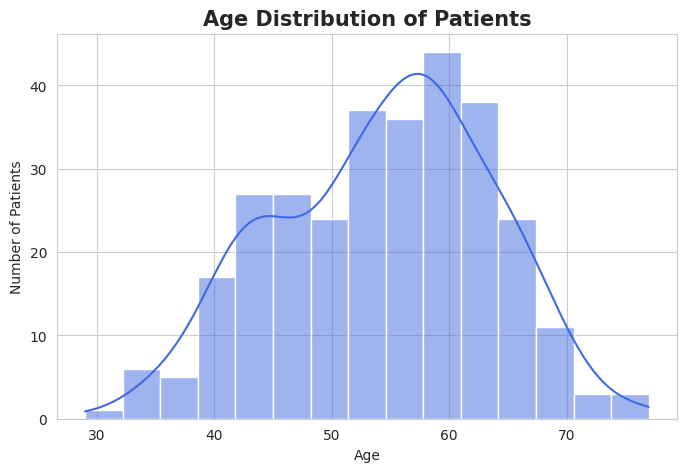

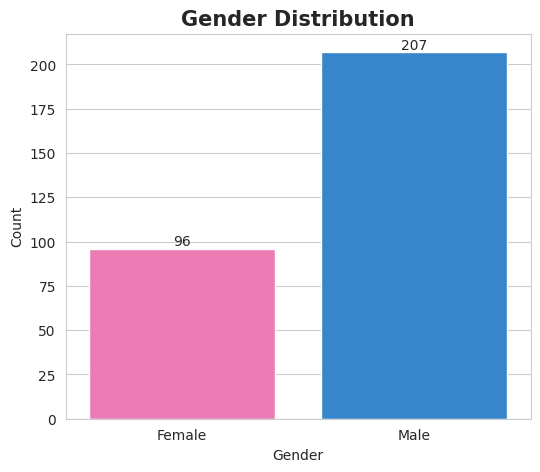

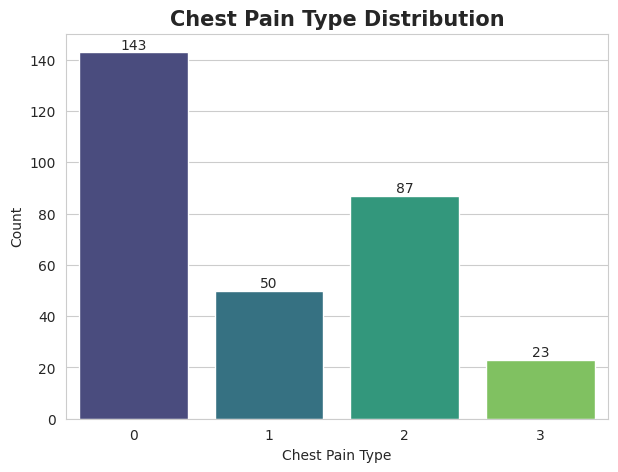

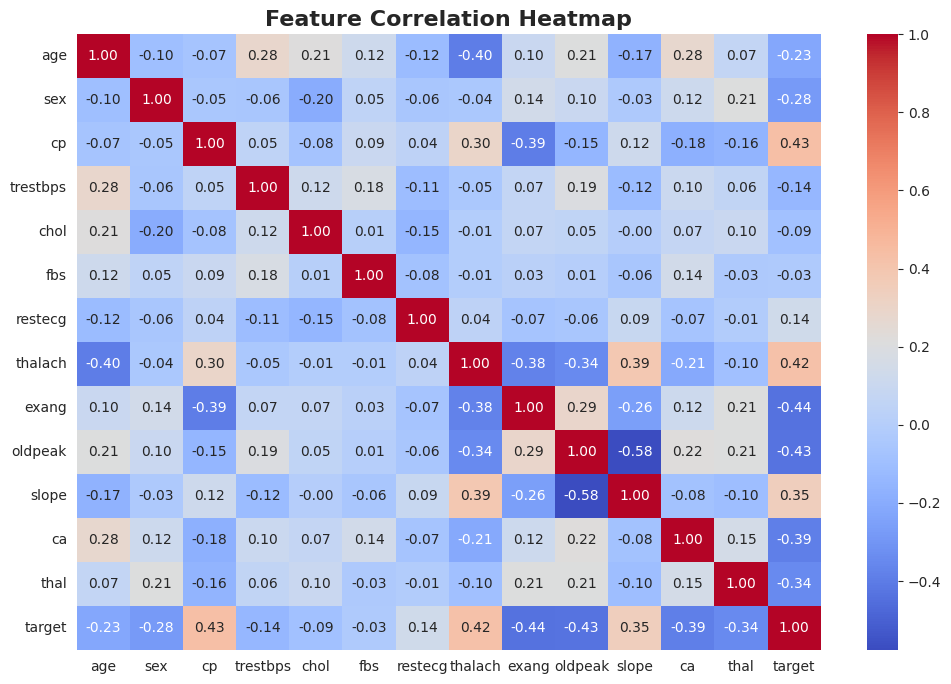


✅ Exploratory Data Analysis Completed Successfully!


In [9]:
# ==========================================================
# CELL 5 : Exploratory Data Analysis (EDA)
# ==========================================================

print("=" * 70)
print("      EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 70)

# ----------------------------------------------------------
# 1. Age Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=15, kde=True, color="royalblue")

plt.title("Age Distribution of Patients", fontsize=15, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


# ----------------------------------------------------------
# 2. Gender Distribution
# ----------------------------------------------------------

plt.figure(figsize=(6,5))

gender_labels = ["Female", "Male"]

ax = sns.countplot(
    data=df,
    x="sex",
    palette=["#FF69B4", "#1E88E5"]
)

plt.title("Gender Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.xticks([0,1], gender_labels)

for container in ax.containers:
    ax.bar_label(container)

plt.show()


# ----------------------------------------------------------
# 3. Chest Pain Type Distribution
# ----------------------------------------------------------

plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="cp",
    palette="viridis"
)

plt.title("Chest Pain Type Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


# ----------------------------------------------------------
# 4. Correlation Heatmap
# ----------------------------------------------------------

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight="bold")

plt.show()

print("\n✅ Exploratory Data Analysis Completed Successfully!")

**Data Cleaning, Feature Selection & Train-Test Split**

In [10]:
# ==========================================================
# CELL 6 : Data Preprocessing
# ==========================================================

print("=" * 70)
print("          DATA PREPROCESSING")
print("=" * 70)

# ----------------------------------------------------------
# Step 1 : Remove Duplicate Records
# ----------------------------------------------------------

duplicates = df.duplicated().sum()

print(f"\nDuplicate Records Before Cleaning : {duplicates}")

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print(f"Duplicate Records After Cleaning  : {duplicates_after}")

# ----------------------------------------------------------
# Step 2 : Feature Selection
# ----------------------------------------------------------

X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures Shape :", X.shape)
print("Target Shape   :", y.shape)

# ----------------------------------------------------------
# Step 3 : Train-Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split Completed Successfully!")

print(f"\nTraining Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

# ----------------------------------------------------------
# Step 4 : Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Applied Successfully!")

# ----------------------------------------------------------
# Final Summary
# ----------------------------------------------------------

print("\n" + "="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"Total Samples : {len(df)}")
print(f"Training Data : {len(X_train)}")
print(f"Testing Data  : {len(X_test)}")

print("\nData is Ready for Machine Learning Models!")

print("\n✅ Cell 6 Executed Successfully!")

          DATA PREPROCESSING

Duplicate Records Before Cleaning : 1
Duplicate Records After Cleaning  : 0

Features Shape : (302, 13)
Target Shape   : (302,)

Train-Test Split Completed Successfully!

Training Samples : 241
Testing Samples  : 61

Feature Scaling Applied Successfully!

PREPROCESSING SUMMARY
Total Samples : 302
Training Data : 241
Testing Data  : 61

Data is Ready for Machine Learning Models!

✅ Cell 6 Executed Successfully!


**Train Multiple Machine Learning Models**

In [11]:
# ==========================================================
# CELL 7 : Train Multiple Machine Learning Models
# ==========================================================

print("=" * 70)
print("         MACHINE LEARNING MODEL TRAINING")
print("=" * 70)

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to store accuracy
accuracy_results = {}

# Dictionary to store trained models
trained_models = {}

print("\nTraining Models...\n")

for name, model in models.items():

    # Logistic Regression & KNN need scaled data
    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    accuracy_results[name] = accuracy
    trained_models[name] = model

    print(f"{name:<25} Accuracy : {accuracy:.4f}")

# ----------------------------------------------------------
# Accuracy Comparison Table
# ----------------------------------------------------------

results_df = pd.DataFrame({
    "Model": accuracy_results.keys(),
    "Accuracy": accuracy_results.values()
})

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

display(results_df)

# ----------------------------------------------------------
# Best Model
# ----------------------------------------------------------

best_model_name = results_df.loc[0, "Model"]
best_accuracy = results_df.loc[0, "Accuracy (%)"]

print("\n🏆 Best Performing Model")
print(f"Model    : {best_model_name}")
print(f"Accuracy : {best_accuracy:.2f}%")

print("\n✅ All Models Trained Successfully!")

         MACHINE LEARNING MODEL TRAINING

Training Models...

Logistic Regression       Accuracy : 0.7869
Decision Tree             Accuracy : 0.7213
Random Forest             Accuracy : 0.7869
K-Nearest Neighbors       Accuracy : 0.8033

MODEL COMPARISON


,Model,Accuracy,Accuracy (%)
0,K-Nearest Neighbors,0.803279,80.327869
1,Logistic Regression,0.786885,78.688525
2,Random Forest,0.786885,78.688525
3,Decision Tree,0.721311,72.131148



🏆 Best Performing Model
Model    : K-Nearest Neighbors
Accuracy : 80.33%

✅ All Models Trained Successfully!


## **Best Model Evaluation**

          BEST MODEL EVALUATION

Best Model : K-Nearest Neighbors
Accuracy   : 80.33%


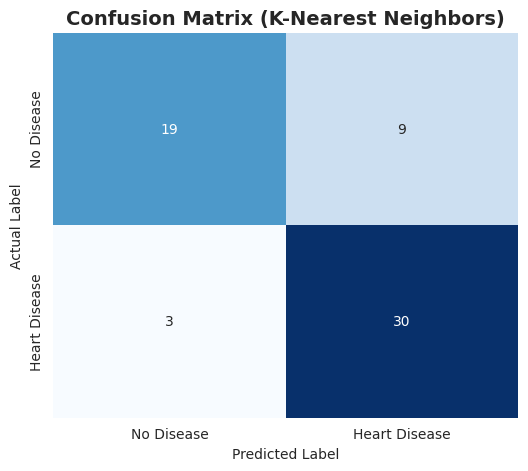


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


✅ Model Evaluation Completed Successfully!


In [12]:
# ==========================================================
# CELL 8 : Best Model Evaluation
# ==========================================================

print("=" * 70)
print("          BEST MODEL EVALUATION")
print("=" * 70)

# ----------------------------------------------------------
# Select Best Model
# ----------------------------------------------------------

best_model = trained_models[best_model_name]

# Use scaled data only for Logistic Regression & KNN
if best_model_name in ["Logistic Regression", "K-Nearest Neighbors"]:
    y_pred = best_model.predict(X_test_scaled)
else:
    y_pred = best_model.predict(X_test)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print(f"\nBest Model : {best_model_name}")
print(f"Accuracy   : {accuracy*100:.2f}%")

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Disease","Heart Disease"],
    yticklabels=["No Disease","Heart Disease"]
)

plt.title(f"Confusion Matrix ({best_model_name})",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred))

print("\n✅ Model Evaluation Completed Successfully!")

**Accuracy Visualization, Sample Prediction & Final Conclusion**

          FINAL PROJECT RESULTS


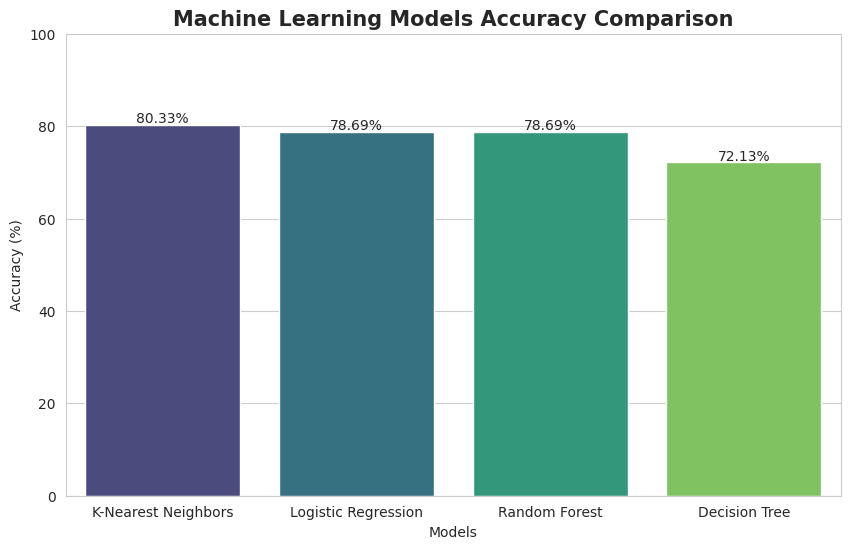


SAMPLE PATIENT PREDICTION

Prediction Result:
Heart Disease Detected

PROJECT SUMMARY
Dataset Used        : Heart Disease Dataset
Problem Type        : Binary Classification
Best Model          : K-Nearest Neighbors
Best Accuracy       : 80.33%
Training Samples    : 241
Testing Samples     : 61

Project Completed Successfully!

Thank you DecodeLabs for providing this internship project opportunity.

Developed by: Shifa


In [13]:
# ==========================================================
# CELL 9 : Final Results & Sample Prediction
# ==========================================================

print("=" * 70)
print("          FINAL PROJECT RESULTS")
print("=" * 70)

# ----------------------------------------------------------
# Accuracy Comparison Chart
# ----------------------------------------------------------

plt.figure(figsize=(10,6))

chart = sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy (%)",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Machine Learning Models Accuracy Comparison",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.ylim(0,100)

# Add values on top of bars
for i, value in enumerate(results_df["Accuracy (%)"]):
    plt.text(i, value+0.5, f"{value:.2f}%", ha="center", fontsize=10)

plt.show()

# ----------------------------------------------------------
# Sample Prediction
# ----------------------------------------------------------

print("\n" + "="*70)
print("SAMPLE PATIENT PREDICTION")
print("="*70)

sample_patient = X.iloc[[0]]

if best_model_name in ["Logistic Regression", "K-Nearest Neighbors"]:
    sample_prediction = best_model.predict(
        scaler.transform(sample_patient)
    )[0]
else:
    sample_prediction = best_model.predict(sample_patient)[0]

print("\nPrediction Result:")

if sample_prediction == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease Detected")

# ----------------------------------------------------------
# Final Summary
# ----------------------------------------------------------

print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"Dataset Used        : Heart Disease Dataset")
print(f"Problem Type        : Binary Classification")
print(f"Best Model          : {best_model_name}")
print(f"Best Accuracy       : {best_accuracy:.2f}%")
print(f"Training Samples    : {len(X_train)}")
print(f"Testing Samples     : {len(X_test)}")

print("\nProject Completed Successfully!")

print("\nThank you DecodeLabs for providing this internship project opportunity.")

print("\nDeveloped by: Shifa")

**Advanced Evaluation & Model Deployment**

     ADVANCED MODEL EVALUATION & DEPLOYMENT

Generating ROC Curve...


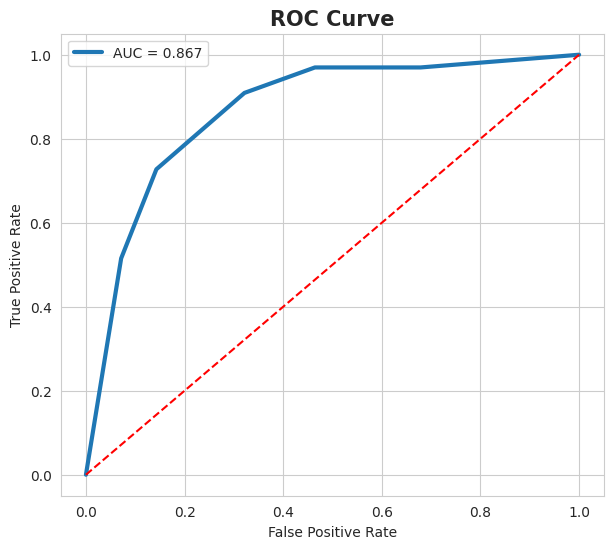


ROC-AUC Score : 0.8674

Feature Importance is only available for Random Forest in this notebook.

Model Saved Successfully!
File Name : heart_disease_model.pkl

FINAL CONCLUSION

Project Name :
Heart Disease Prediction Using Machine Learning

Objective :
Predict whether a patient has heart disease using
Supervised Machine Learning Algorithms.

Best Model :
K-Nearest Neighbors

Model Accuracy :
80.33%

ROC-AUC Score :
0.867

Project Status :
SUCCESSFULLY COMPLETED

Developed By :
Shifa

Internship :
DecodeLabs AI Internship

THANK YOU!


In [14]:
# ==========================================================
# CELL 10 : Advanced Model Evaluation & Deployment
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score
import joblib

print("=" * 70)
print("     ADVANCED MODEL EVALUATION & DEPLOYMENT")
print("=" * 70)

# ----------------------------------------------------------
# ROC Curve
# ----------------------------------------------------------

print("\nGenerating ROC Curve...")

# Probability Prediction
if best_model_name in ["Logistic Regression", "K-Nearest Neighbors"]:
    y_prob = best_model.predict_proba(X_test_scaled)[:,1]
else:
    y_prob = best_model.predict_proba(X_test)[:,1]

# ROC Values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve", fontsize=15, fontweight="bold")
plt.legend()

plt.show()

print(f"\nROC-AUC Score : {auc_score:.4f}")

# ----------------------------------------------------------
# Feature Importance
# ----------------------------------------------------------

if best_model_name == "Random Forest":

    print("\nTop Important Features")

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(feature_importance)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False
    )

    plt.title("Feature Importance")
    plt.show()

else:

    print("\nFeature Importance is only available for Random Forest in this notebook.")

# ----------------------------------------------------------
# Save Model
# ----------------------------------------------------------

joblib.dump(best_model,"heart_disease_model.pkl")

print("\nModel Saved Successfully!")

print("File Name : heart_disease_model.pkl")

# ----------------------------------------------------------
# Final Conclusion
# ----------------------------------------------------------

print("\n" + "="*70)
print("FINAL CONCLUSION")
print("="*70)

print(f"""
Project Name :
Heart Disease Prediction Using Machine Learning

Objective :
Predict whether a patient has heart disease using
Supervised Machine Learning Algorithms.

Best Model :
{best_model_name}

Model Accuracy :
{best_accuracy:.2f}%

ROC-AUC Score :
{auc_score:.3f}

Project Status :
SUCCESSFULLY COMPLETED

Developed By :
Shifa

Internship :
DecodeLabs AI Internship
""")

print("="*70)
print("THANK YOU!")
print("="*70)

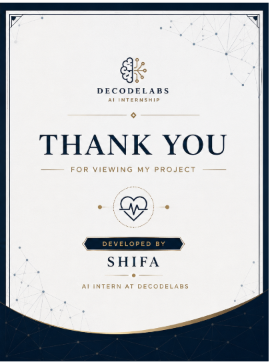